In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pycontrails import Fleet

In [8]:
dff = pd.read_parquet("../data/dff_matthes_2025_dahlmann_2025_EAGWP100_[0, 1000]_True.parquet")
fleetf = Fleet(data=dff)
print(f"Fleet contains {fleetf.n_flights} flights")

dfo = pd.read_parquet("../data/dfo_matthes_2025_dahlmann_2025_EAGWP100_[0, 1000]_True.parquet")
fleeto = Fleet(data=dfo)
print(f"Fleet contains {fleeto.n_flights} flights")

Fleet contains 4112 flights
Fleet contains 4112 flights


In [9]:
from cane.labels import friendly_days, friendly_firs

In [10]:
meta = pd.read_parquet("../data/concerto_sol2_ex2_filed_meta.parquet")

from cane.trajectory import flight_haul_type_by_time

meta = flight_haul_type_by_time(meta, classification="IATA")
meta = pd.merge(
    dff.groupby("flight_id").day.first(),
    meta,
    on="flight_id",
)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely import centroid
from cane.airspaces.borealis import Borealis
from shapely.geometry import shape

city_pairs = (meta[['dep', 'dest']]
              .apply(lambda x: pd.Series(sorted(x)), axis=1)
              .drop_duplicates()
              .set_axis(['dep', 'dest'], axis=1))

import airportsdata

airports = airportsdata.load()
airports_df = pd.DataFrame(airports.values())
city_pairs = pd.merge(
    city_pairs,
    airports_df[["icao", "lat", "lon"]],
    left_on="dep",
    right_on="icao",
).drop(columns=["icao"])
city_pairs = pd.merge(
    city_pairs,
    airports_df[["icao", "lat", "lon"]],
    left_on="dest",
    right_on="icao",
    suffixes=("_dep", "_dest"),
).drop(columns=["icao"])
city_pairs  # since we treat AMS<>BCN the same as BCN<>AMS, the dep / dest is not necessarily correct

import ssl, certifi

ssl._create_default_https_context = ssl._create_unverified_context  # quick temporary fix for cartopy

In [12]:
meta_tmp = meta.copy()
meta_tmp.loc[meta_tmp["haul_type"] == "Ultra-long", "haul_type"] = "Long"  # mark ultra-longs as long
flights_per_day_and_haul = meta_tmp.groupby(["day", "haul_type"]).size().rename("count").reset_index()

df = flights_per_day_and_haul
ids = df["day"].unique()
subs = df["haul_type"].unique()

# Cartesian product of all combinations
all_combos = pd.MultiIndex.from_product([ids, subs], names=["day", "haul_type"]).to_frame(index=False)

# Merge with original data
df_complete = all_combos.merge(df, on=["day", "haul_type"], how="left")
df_complete = df_complete.fillna(0)
# df_complete

In [13]:
Borealis().feature_collection["features"]

[{'type': 'Feature',
  'geometry': {'type': 'Polygon',
   'coordinates': [[[25.86667, 59.88333],
     [25.65833, 59.89333],
     [25.61667, 59.89556],
     [25.585, 59.89694],
     [25.42, 59.90444],
     [25.33333, 59.90833],
     [25.33111, 59.90833],
     [25.25167, 59.90417],
     [25.04417, 59.89361],
     [25.03333, 59.89306],
     [24.99694, 59.89083],
     [24.85, 59.88333],
     [24.66528, 59.84472],
     [24.66222, 59.84389],
     [24.4525, 59.79944],
     [24.38667, 59.78528],
     [24.17056, 59.73889],
     [24.13889, 59.73167],
     [23.99194, 59.7],
     [23.87667, 59.67472],
     [23.84083, 59.66694],
     [23.81389, 59.66111],
     [23.15583, 59.51472],
     [23.08278, 59.4975],
     [23.05333, 59.49083],
     [22.9825, 59.47472],
     [22.93944, 59.46472],
     [22.92972, 59.4625],
     [22.87694, 59.45056],
     [22.80694, 59.43444],
     [22.74694, 59.42056],
     [22.17861, 59.2875],
     [22.14, 59.27833],
     [21.94667, 59.23194],
     [21.75556, 59.18611],
     

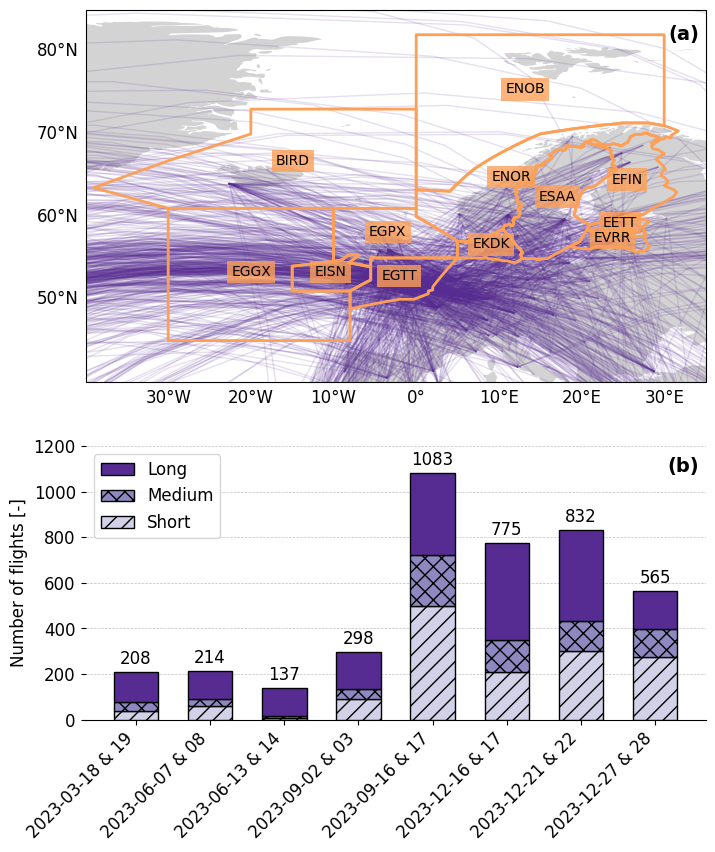

In [14]:
from matplotlib.gridspec import GridSpec


# import matplotlib.ticker as mticker


def plot_merged(cps, df_complete, save_path=None):
    fig = plt.figure(figsize=(8, 10))
    gs = GridSpec(
        2, 1,
        height_ratios=[1.8, 1],  # adjust if you want map taller
        hspace=0.01,  # vertical space
        figure=fig
    )

    # ============================
    # 1) TOP SUBPLOT – MAP
    # ============================
    ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
    ax1.set_extent([-40, 35, 40, 85], crs=ccrs.PlateCarree())

    ax1.add_feature(cfeature.LAND, facecolor="lightgray")

    gl = ax1.gridlines(draw_labels=True, linestyle="--", linewidth=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

    # gl.xlocator = mticker.FixedLocator(range(-40, 40, 10))
    # gl.ylocator = mticker.FixedLocator(range(40, 86, 10))

    # FIR boundaries from Borealis
    for feature in Borealis().feature_collection["features"]:
        fir = feature["properties"]["airspace"]
        polygon = shape(feature["geometry"])

        ax1.add_geometries([polygon], crs=ccrs.PlateCarree(),
                           facecolor="none",
                           edgecolor=sns.color_palette("Oranges")[2],
                           zorder=15,
                           linewidth=2)

        cen = centroid(polygon)
        ax1.text(
            cen.x, cen.y, fir[:4], fontsize=10, ha="center",
            zorder=20,
            transform=ccrs.PlateCarree(),
            bbox=dict(boxstyle="square",
                      ec="none",
                      fc=sns.color_palette("Oranges")[2],
                      alpha=0.8)
        )

    # City-pair lines
    for idx, cp in cps.iterrows():
        ax1.plot(
            [cp.lon_dep, cp.lon_dest],
            [cp.lat_dep, cp.lat_dest],
            transform=ccrs.Geodetic(),
            color=sns.color_palette("Purples")[5],
            linewidth=1,
            alpha=0.15
        )

    # ============================
    # 2) BOTTOM SUBPLOT – BAR CHART
    # ============================
    ax2 = fig.add_subplot(gs[1, 0])

    my_colors = {
        "Short": sns.color_palette("Purples")[1],
        "Medium": sns.color_palette("Purples")[3],
        "Long": sns.color_palette("Purples")[5],
        "Ultra-long": sns.color_palette("Purples")[5]
    }

    my_hatches = {
        "Short": "//",
        "Medium": "xx",
        "Long": "",
        "Ultra-long": "xxx"
    }

    bottom = np.zeros(df_complete.day.nunique())
    keys = ["Short", "Medium", "Long"]  #, "Ultra-long"]

    for key in keys:
        vals = df_complete.query("haul_type == @key")
        bars = ax2.bar(
            vals["day"] - 1,
            vals["count"],
            width=0.6,
            bottom=bottom,
            label=key,
            color=my_colors[key],
            hatch=my_hatches[key],
            edgecolor="black",
            zorder=10,
        )
        bottom += vals["count"].values

    ax2.bar_label(bars, padding=3, fmt="%.0f", fontsize=12)
    ax2.set_xticks(range(8))

    ax2.set_xticklabels(friendly_days, fontsize=12, rotation=45, ha="right")

    ax2.set_ylim([0, 1200])
    ax2.set_ylabel("Number of flights [-]", fontsize=12)

    ax2.grid(axis="y")
    ax1.tick_params(labelsize=12)
    ax2.tick_params(labelsize=12)

    handles, labels = ax2.get_legend_handles_labels()
    ax2.legend(handles[::-1], labels[::-1], loc="upper left", fontsize=12)

    # plt.tight_layout()
    ax1.text(
        0.99, 0.96, "(a)", zorder=100,
        transform=ax1.transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="right"
    )

    ax2.text(
        0.99, 0.96, "(b)",
        transform=ax2.transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="right"
    )

    ax2.spines['top'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    ax2.yaxis.grid(True, color='gray', linewidth=0.5, alpha=0.5, linestyle='--')

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    else:
        plt.show()


plot_merged(city_pairs, df_complete)  #, save_path="./figures/fig01.png")

# 1 and 2 merged

In [15]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from cane.airspaces.borealis import borealis_airspaces_piontek2025


# flight count
def flight_count_matrix(df):
    return (
        df.groupby(["day", "fir"]).flight_id.nunique().rename("count").reset_index()
        .pivot(index="day", columns="fir", values="count")
    )[borealis_airspaces_piontek2025]

In [16]:
days_2rows = [
    '03-18\n03-19',
    '06-07\n06-08',
    '06-13\n06-14',
    '09-02\n09-03',
    '09-16\n09-17',
    '12-16\n12-17',
    '12-21\n12-22',
    '12-27\n12-27'
]

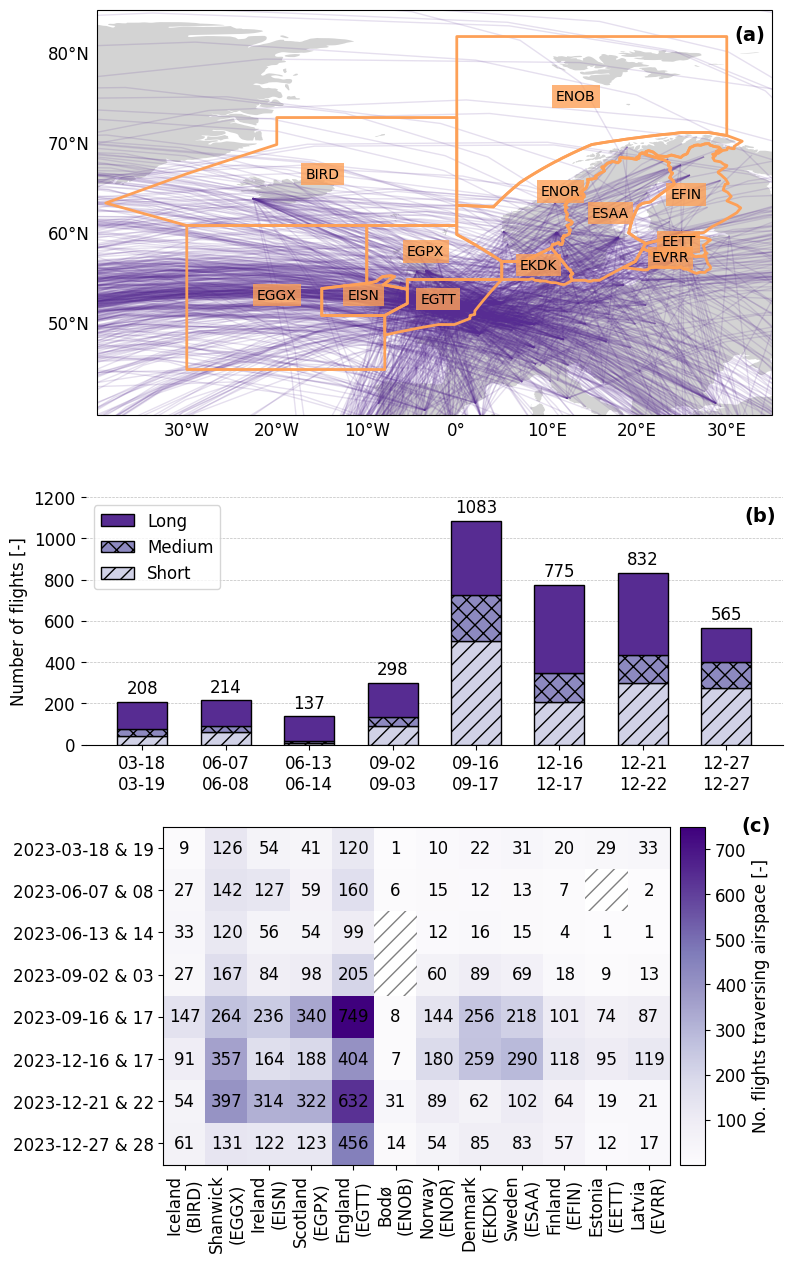

In [18]:
from matplotlib.gridspec import GridSpec


# import matplotlib.ticker as mticker


def plot_merged_three(cps, df_complete, matrix, save_path=None):
    fig = plt.figure(figsize=(9, 15))
    gs = GridSpec(
        3, 1,
        height_ratios=[1.8, 1.1, 1.5],  # adjust if you want map taller
        hspace=0.25,  # vertical space
        figure=fig
    )

    # ============================
    # 1) TOP SUBPLOT – MAP
    # ============================
    ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
    ax1.set_extent([-40, 35, 40, 85], crs=ccrs.PlateCarree())

    ax1.add_feature(cfeature.LAND, facecolor="lightgray")

    gl = ax1.gridlines(draw_labels=True, linestyle="--", linewidth=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

    # gl.xlocator = mticker.FixedLocator(range(-40, 40, 10))
    # gl.ylocator = mticker.FixedLocator(range(40, 86, 10))

    # FIR boundaries from Borealis
    for feature in Borealis().feature_collection["features"]:
        fir = feature["properties"]["airspace"]
        polygon = shape(feature["geometry"])

        ax1.add_geometries([polygon], crs=ccrs.PlateCarree(),
                           facecolor="none",
                           edgecolor=sns.color_palette("Oranges")[2],
                           zorder=15,
                           linewidth=2)

        cen = centroid(polygon)
        ax1.text(
            cen.x, cen.y, fir[:4], fontsize=10, ha="center",
            zorder=20,
            transform=ccrs.PlateCarree(),
            bbox=dict(boxstyle="square",
                      ec="none",
                      fc=sns.color_palette("Oranges")[2],
                      alpha=0.8)
        )

    # City-pair lines
    for idx, cp in cps.iterrows():
        ax1.plot(
            [cp.lon_dep, cp.lon_dest],
            [cp.lat_dep, cp.lat_dest],
            transform=ccrs.Geodetic(),
            color=sns.color_palette("Purples")[5],
            linewidth=1,
            alpha=0.15
        )

    # ============================
    # 2) BOTTOM SUBPLOT – BAR CHART
    # ============================
    ax2 = fig.add_subplot(gs[1, 0])

    my_colors = {
        "Short": sns.color_palette("Purples")[1],
        "Medium": sns.color_palette("Purples")[3],
        "Long": sns.color_palette("Purples")[5],
        "Ultra-long": sns.color_palette("Purples")[5]
    }

    my_hatches = {
        "Short": "//",
        "Medium": "xx",
        "Long": "",
        "Ultra-long": "xxx"
    }

    bottom = np.zeros(df_complete.day.nunique())
    keys = ["Short", "Medium", "Long"]  #, "Ultra-long"]

    for key in keys:
        vals = df_complete.query("haul_type == @key")
        bars = ax2.bar(
            vals["day"] - 1,
            vals["count"],
            width=0.6,
            bottom=bottom,
            label=key,
            color=my_colors[key],
            hatch=my_hatches[key],
            edgecolor="black",
            zorder=10,
        )
        bottom += vals["count"].values

    ax2.bar_label(bars, padding=3, fmt="%.0f", fontsize=12)
    ax2.set_xticks(range(8))

    ax2.set_xticklabels(days_2rows, fontsize=12)  #, rotation=45, ha="right")

    ax2.set_ylim([0, 1200])
    ax2.set_ylabel("Number of flights [-]", fontsize=12)

    ax2.grid(axis="y")
    ax1.tick_params(labelsize=12)
    ax2.tick_params(labelsize=12)

    handles, labels = ax2.get_legend_handles_labels()
    ax2.legend(handles[::-1], labels[::-1], loc="upper left", fontsize=12)

    ### Figure (c)
    ################
    ################
    ax3 = fig.add_subplot(gs[2, 0])
    cax = ax3.matshow(matrix, cmap="Purples")

    ax3.grid(None)

    # Hatch NaN cells
    for (i, j), val in np.ndenumerate(matrix):
        if np.isnan(val):
            ax3.add_patch(
                plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor='none', hatch='//', edgecolor='gray', linewidth=0)
            )
        else:
            ax3.text(j, i, f"{int(val)}", ha='center', va='center', color='black', fontsize=12)

    divider = make_axes_locatable(ax3)
    cbar_ax = divider.append_axes("right", size="5%", pad=0.1)
    cbar = fig.colorbar(cax, cax=cbar_ax)
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label(label="No. flights traversing airspace [-]", fontsize=12)

    ax3.set_xticks(range(len(matrix.columns)))
    # ax.set_xticklabels([f"{fir[:4]}" for fir in matrix.columns], rotation=45, ha="right")
    ax3.set_xticklabels([f"{friendly_firs[fir[:4]]}\n({fir[:4]})" for fir in matrix.columns], rotation=90,
                        fontsize=12)
    ax3.xaxis.set_ticks_position("bottom")

    ax3.set_yticks(range(len(matrix.index)))
    ax3.set_yticklabels(friendly_days, fontsize=12)
    ax3.yaxis.set_ticks_position("left")

    ax3.grid(None)

    # plt.tight_layout()
    ax1.text(
        0.99, 0.96, "(a)", zorder=100,
        transform=ax1.transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="right"
    )

    ax2.text(
        0.99, 0.96, "(b)",
        transform=ax2.transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="right"
    )

    ax3.text(
        1.2, 1.03, "(c)",
        transform=ax3.transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="right"
    )

    ax2.spines['top'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    ax2.yaxis.grid(True, color='gray', linewidth=0.5, alpha=0.5, linestyle='--')

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    else:
        plt.show()


plot_merged_three(city_pairs, df_complete, flight_count_matrix(dff), save_path="./figures/fig01.png")